# Titanium image to damask input
## Guy Bowker

In [1]:
from skimage import io
# for resizing, scaling, cropping
from skimage.transform import rescale, resize
from skimage.transform import rotate
from skimage.segmentation import clear_border
from skimage.util import crop

# for binarizing
from skimage import data
from skimage.filters import threshold_otsu

# for eroding
from skimage.morphology import (erosion, dilation, opening, closing,  # noqa
                                white_tophat)
from skimage import morphology
from skimage.measure import label
from scipy import ndimage

# for plotting
import matplotlib
from matplotlib import pyplot as plt

from defdap.quat import Quat
from beta_reconstruction.crystal_relations import unq_cub_syms, burg_trans

# for analysis
import numpy as np
# import damask
import damask
from damask import Grid

# Load in defdap to calulate corresponding alpha orientations from defined beta orientations:
from defdap.quat import Quat
from beta_reconstruction.crystal_relations import unq_cub_syms, burg_trans

(128, 128)


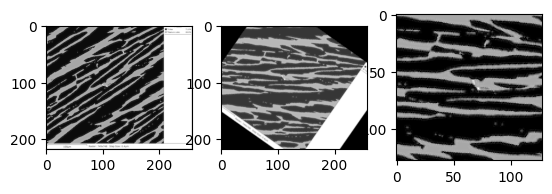

In [2]:
%matplotlib inline
fig, ax = plt.subplots(1,3)
# read in and show image
img = io.imread("1000_degree_celsius-Phase_map.png", as_gray=True)
# img = io.imread("CA_modelled-beta_volfraction_ 0.294599.png", as_gray=True)
ax[0].imshow(img, cmap=plt.cm.gray)

# crop out scale bar and axes
rotated_img = rotate(img,-35)
ax[1].imshow(rotated_img, cmap=plt.cm.gray)
cropped_img = rotated_img[30:30+128, 40:40+128]
ax[2].imshow(cropped_img, cmap=plt.cm.gray)
print(f"{cropped_img.shape}")

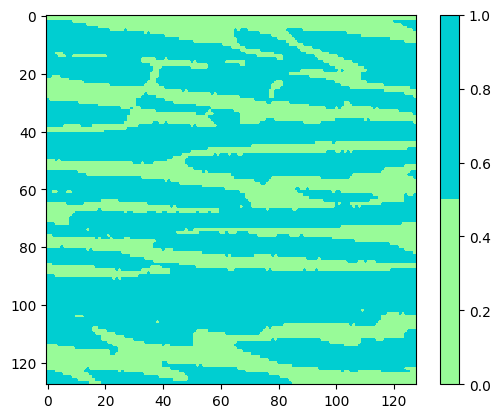

alpha vol frac:82.6328125
beta vol frac: 45.3671875


In [13]:
# Binarize img
thresh = threshold_otsu(cropped_img) # automatically calculate threshold
binary_img = cropped_img < thresh # switch sign to switch b/w assignment

cmap = matplotlib.colors.ListedColormap(['palegreen', 'darkturquoise']) # define cmap colours
plt.imshow(binary_img, cmap=cmap)
plt.colorbar()
plt.show()

print(f"alpha vol frac:{len(binary_img[binary_img==1])/len(binary_img)}")
print(f"beta vol frac: {len(binary_img[binary_img==0])/len(binary_img)}")

## alpha laths different constituents

5807
10577
16384 16384
all consts: [    0     1     2 ... 16381 16382 16383]
const of phase_idx 0: [   0    1    2 ... 5804 5805 5806]
const of phase_idx 1: [ 5807  5808  5809 ... 16381 16382 16383]


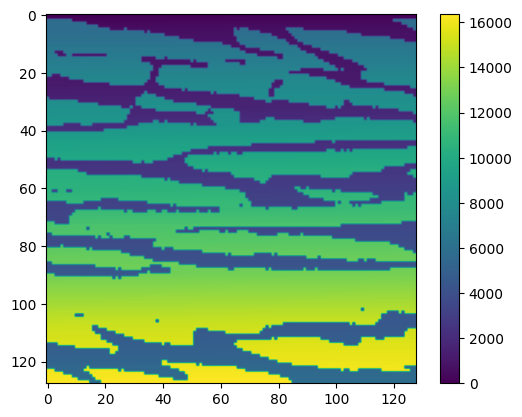

In [14]:

labelled_img = label(binary_img)
seg_img = labelled_img.copy()
total_pixels = labelled_img.shape[0]*labelled_img.shape[1]
beta_pixels = len(labelled_img[labelled_img==0]) ; print(beta_pixels)
alpha_pixels = len(labelled_img[labelled_img>0]) ; print(alpha_pixels)
print(total_pixels, beta_pixels+alpha_pixels)

seg_img[labelled_img==0] = np.arange(0, beta_pixels)
seg_img[labelled_img>0] = np.arange(beta_pixels, total_pixels)

plt.imshow(seg_img)
plt.colorbar()
all_consts = np.unique(seg_img)
print(f"all consts: {all_consts}")
beta_consts = np.unique(seg_img[binary_img==0])
alpha_consts = np.unique(seg_img[binary_img==1])
print(f"const of phase_idx 0: {beta_consts}")
print(f"const of phase_idx 1: {alpha_consts}")


## recrystallise a chosen phase (skip for conghuis - already at temperature!)

Size (503, 503)
alpha: 45.8825575374789
beta: 54.11744246252109


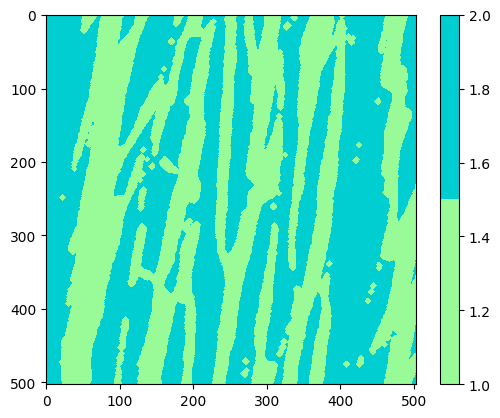

In [4]:
# erode the image to get ~50:50 alpha:beta
erosion = ndimage.binary_erosion(binary_img, iterations=4).astype(np.uint8)+1 # makes it work - dont ask how
mask = erosion > 1 # prevents border
eroded_img = erosion[np.ix_(mask.any(0),mask.any(0))]

plt.imshow(eroded_img, cmap=cmap) ; plt.colorbar() # Show image with colourbar
print("Size", eroded_img.shape)

# Calcualte vol_fracs:
alpha = (np.count_nonzero(eroded_img == 1) / eroded_img.shape[0]**2 ) * 100
beta = (np.count_nonzero(eroded_img == 2) / eroded_img.shape[0]**2 ) * 100
total = alpha + beta
print(f"alpha: {alpha}\nbeta: {beta}")

## Resized or change resolution so computable
Either select an area or decrease res of whole image

Size (512, 512)
alpha: 70.51582336425781
beta: 29.484176635742188


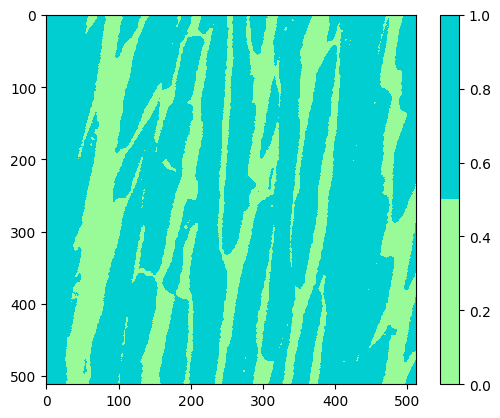

In [5]:
grid_size = 512
selected_img = binary_img[0:grid_size, 0:grid_size]
# selected_img = eroded_img[0:grid_size, 0:grid_size]
plt.imshow(selected_img, cmap=cmap) ; plt.colorbar()

print("Size", selected_img.shape)
# find vol_fracs:
alpha = (np.count_nonzero(selected_img == 1) / selected_img.shape[0]**2 ) * 100
beta = (np.count_nonzero(selected_img == 0) / selected_img.shape[0]**2 ) * 100
total = alpha + beta
print(f"alpha: {alpha}\nbeta: {beta}")

## Extrude into 3d array

In [15]:
extrude = 32
selected_img = seg_img
microstructure = np.ndarray((selected_img.shape[0], extrude, selected_img.shape[1]))
for extrusion in range(0, extrude):
    microstructure[:, extrusion, :] = selected_img
microstructure.shape

(128, 32, 128)

In [16]:

## Encase in alpha
buffer = 8
microstructure[0:buffer, :, :] = microstructure.max()
microstructure[:, 0:buffer, :] = microstructure.max()
microstructure[:, :, 0:buffer] = microstructure.max()
microstructure[-buffer:, :, :] = microstructure.max()
microstructure[:, -buffer:, :] = microstructure.max()
microstructure[:, :, -buffer:] = microstructure.max()


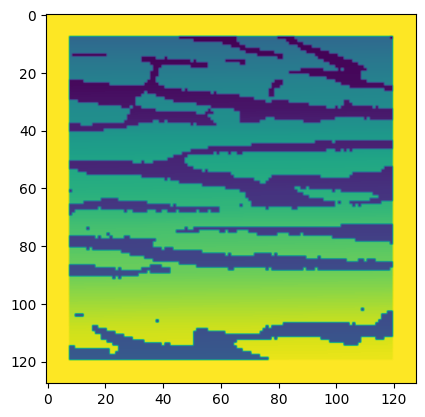

In [17]:
plt.imshow(microstructure[:,8,:])

---
# Define texture of VE
## Generating BOR alpha-beta ori pair in quats for single-colony models

In [18]:
def random_unit_vector():
    """
    Generates a random 3D unit vector.
    """
    phi = np.random.uniform(0, 2*np.pi)
    costheta = np.random.uniform(-1, 1)
    theta = np.arccos(costheta)
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)
    return np.array([x, y, z])

def random_quaternion():
    """
    Generates a random unit quaternion.
    """
    v = random_unit_vector()
    w = np.random.uniform(0, 2*np.pi)
    return np.array([np.cos(w/2), *np.sin(w/2) * v])

def alphabeta_BOR_euler(alpha_euler):
    phi1 = alpha_euler[0]*(np.pi/180)
    PHI = alpha_euler[1]*(np.pi/180)
    phi2 = alpha_euler[2]*(np.pi/180)
    alphaquat = Quat.fromEulerAngles(phi1, PHI, phi2)
    beta_eulers = []
    for sym in unq_cub_syms:
        BOR_betaquat = burg_trans.conjugate * sym * alphaquat
        BOR_beta_euler = Quat.eulerAngles(BOR_betaquat)*(180/np.pi)
        beta_eulers.append(BOR_beta_euler.astype(int))
    return beta_eulers
    

def pertubate_euler(ori, sigma=1):
    # Generate spread alpha and BOR spread beta
    # alpha euler (90,90,0)==basalTD, (0,90,0)==basalRD, (0,0,0)==basalND
    phi1 = ori[0]
    PHI = ori[1]
    phi2 = ori[2]
    # pertubate
    phi1_pert = phi1 + np.random.uniform(-sigma,sigma)
    PHI_pert = PHI + np.random.uniform(-sigma,sigma)
    phi2_pert = phi2 + np.random.uniform(-sigma,sigma)
    # convert to quat
    quat = Quat.fromEulerAngles(phi1_pert, PHI_pert, phi2_pert)
    return quat


def random_float_excluding(start, end, exclude=[]):
    while True:
        rand_float = np.random.uniform(start, end)
        if round(rand_float, 0) not in exclude:
            return rand_float
def perturbate_quat(quat, sigma):
    w1, x1, y1, z1 = quat[0], quat[1], quat[2], quat[3]
    # random choice of axis excluding zero
    axis = np.array([np.random.uniform(-1, 1),
                     np.random.uniform(-1, 1),
                     np.random.uniform(-1, 1)])
    # Normalize axis to get unit vector
    axis = axis / np.linalg.norm(axis)
    sin_half_angle = np.sin(sigma/2.0)
    # Create perturbation quat
    w2, x2, y2, z2 = np.array([np.cos(sigma/2.0), 
                               sin_half_angle * axis[0], 
                               sin_half_angle * axis[1], 
                               sin_half_angle * axis[2]])
    
    # Multiply the original quaternion by the perturbation quaternion
    return np.array([w1*w2 - x1*x2 - y1*y2 - z1*z2,
                     w1*x2 + x1*w2 + y1*z2 - z1*y2,
                     w1*y2 - x1*z2 + y1*w2 + z1*x2,
                     w1*z2 + x1*y2 - y1*x2 + z1*w2])
    

def BOR_beta(alpha_ori, sigma=1):
    """
    Generate a buncha perts around a BOR beta ori from central alpha ori
    """
    # For defined alpha ori, get BOR prior beta quat
    BOR_beta_quat = burg_trans.conjugate * unq_cub_syms[0] * alpha_ori  # from dafdap
    # pick first BOR beta, convert back to euler
    BOR_beta_euler = Quat.eulerAngles(BOR_beta_quat)
    # pertubate:
    beta_quat = pertubate_euler(BOR_beta_euler, sigma)
    return beta_quat


In [22]:

orientations = np.ndarray(shape=(all_consts.shape[0], 4))
phases = []
    
sigma = 0.3

alpha_euler = np.array([30, 0, 0])*np.pi/180
alphaQuat = Quat.fromEulerAngles(alpha_euler[0],alpha_euler[1],alpha_euler[2])# takes radians as inputs

# Write oris to .txt to check textures with mtex
alpha_texture = open("alpha_texture.txt", 'w')
alpha_texture.write(f"w\tx\ty\tz\n")
beta_texture = open("beta_texture.txt", 'w')
beta_texture.write(f"w\tx\ty\tz\n")
    
for c, const in enumerate(all_consts):
    if const in beta_consts: # if beta
        beta_quat = BOR_beta(Quat.fromEulerAngles(alpha_euler[0],alpha_euler[1],alpha_euler[2]), sigma)
        orientations[c] = [beta_quat[0], beta_quat[1], beta_quat[2], beta_quat[3]]
        phases.append("Ti_beta")
        beta_texture.write(f"{beta_quat[0]}\t{beta_quat[1]}\t{beta_quat[2]}\t{beta_quat[3]}\n")
    elif const in alpha_consts:
        alpha_quat = perturbate_quat(alphaQuat, sigma)
        orientations[c] = [alpha_quat[0], alpha_quat[1], alpha_quat[2], alpha_quat[3]]
        phases.append("Ti_alpha")
        alpha_texture.write(f"{alpha_quat[0]}\t{alpha_quat[1]}\t{alpha_quat[2]}\t{alpha_quat[3]}\n")
print(f"Written to file {c+1} orientations")

alpha_texture.close()
beta_texture.close()


Written to file 16384 orientations


## Write geom and material inputs into DAMASK

In [20]:

final_VE = microstructure
gridsize = np.array([1, final_VE.shape[1]/final_VE.shape[0], 1])
# flip y so it puts image in right way round
# material_array = np.flip(final_VE, axis=0)

g = Grid(final_VE, gridsize) # g is now geometry file

grid = g.renumber();
grid.save(fname="EBSDconghui_alphabuffer_lowbeta_lathsND", compress=True)

In [23]:

material_yaml = open(f"material.yaml", 'w')
material_yaml.write(f"homogenization:\n\
  SX:\n\
    mechanical:\n\
      type: pass\n\
    N_constituents: 1\n\n\
phase:\n\
  Ti_alpha:\n\
    lattice: hP\n\
  Ti_beta:\n\
    lattice: cI\n\n\
material:\n")
for c in all_consts:
    material_yaml.write(f"- homogenization: SX\n\
  constituents:\n\
  - v: 1.0\n\
    O:\n\
    - {orientations[c][0]}\n\
    - {orientations[c][1]}\n\
    - {orientations[c][2]}\n\
    - {orientations[c][3]}\n\
    phase: {phases[c]}\n")

material_yaml.close()
